Based on: https://github.com/icepack/icepack2/commits/75b5b1413af3ad7d584424f9b4e64ad0bc57988f/notebooks/mismipp-dual-1d.ipynb

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)

import ufl

from ufl.tensors import as_scalar

import scipy as sp

import timeit

## Definitions of the laws

In [21]:
# q is functional and we extract the coefficients, z, and then create a test function, w, 
# on the function space that z was defined on and then replace z by w
def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q) # the comma unpacks a list with just one element so z is the item in the list not the list
    w = fd.TestFunction(z.function_space()) 
    return fd.replace(q, {z: w}) # variable substitution (the new variables are w)

In [22]:
n = 3 #Constant(glen_flow_law)
m = 3 #Constant(weertman_sliding_law)

In the following we define the variational form of the friction law $\langle K |\tau|^2 \tau + f u, \sigma \rangle$.
Next we do the same for the flow law $$\frac{1}{2} h\cdot A\cdot \left(|M|^2 -\frac{\text{tr}(M)^2}{d+1}\right)\cdot \left(\langle M, N\rangle -\frac{\text{tr}(M)\text{tr}(N)}{d+1} \right) - \langle \varepsilon , N \rangle,$$
where $\varepsilon = \frac{\nabla u +\nabla u ^T}{2}$ is the strain rate. <br>
In the first case $\sigma$ is the test function whereas in the second case $N$ is the test function.


In [23]:
def flow_law(dimension, **kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u)) # symmetric part of the gradient of u so 1/2(grad(u)+grad(u)^T)
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx

For momentum balance we get 
$\int -h \langle M, \varepsilon \rangle +\langle \tau-\rho_I g h \nabla s, v\rangle dx+ \int\rho_I \text{avg}(h) \langle \text{jump}(s)\cdot \nu, \text{avg}(v)\rangle dS $, where $\varepsilon = \frac{\nabla v +\nabla v^T}{2}$. <br>
The function $\text{avg}(v)$ means that, when considering the facet between two cells and using the discontinuous Galerkin method, we take 
$\frac{v(+)+v(-)}{2}$. Similarly, $\text{jump}(s)$ gives us the discontinuity of s over different facets.

In [24]:
def momentum_balance(**kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS #fd.avg() gives us the average at a discontinuous spot (so a method for 'DG') 

    return cell_balance + facet_balance

For the terminus we have $\int\frac{\rho_I g h^2-\rho g \min(s-h, 0)}{2}\langle v, \nu\rangle ds$ on the part of the boundary given by 'terminus_ids'.

In [25]:
def terminus(**kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)

In [26]:
def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2

The expression $\int (\text{D}t(h) \eta - \langle h u, \nabla \eta\rangle - a\eta) \text{d}x + \int \text{jump}(h \max(0, \langle u,\nu\rangle))\text{jump}(\eta)\text{d}S 
+\int h \max(0, \langle u,\nu\rangle)\eta \text{d}s + \int h_\text{in}\min(0,\langle u, \nu\rangle)\eta\text{d}s$ gives us the mass balance.

In [27]:
def mass_balance(**kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

## Initialization and setting the values

In [28]:
"""
Initialization of the bed geometry and velocity/height profiles
"""

lx = 610e3
nx = 450

mesh = fd.IntervalMesh(nx, lx, name="mesh")
thickness_element = fd.FiniteElement("DG", "interval", 0)
bed_element = fd.FiniteElement("CG", "interval", 1)
degree = 1

velocity_element = fd.FiniteElement("CG", "interval", degree)
stress_element = fd.FiniteElement("DG", "interval", degree - 1)

Q = fd.FunctionSpace(mesh, thickness_element)
S = fd.FunctionSpace(mesh, bed_element)
V = fd.VectorFunctionSpace(mesh, velocity_element)
Σ = fd.TensorFunctionSpace(mesh, stress_element, symmetry=True)

Lx = Constant(lx)

mesh_dim = mesh.geometric_dimension

In [29]:
"""
We utilize the mismip+ bed
"""
    
B_0 = Constant(-150)
B_2 = Constant(-728.8)
B_4 = Constant(343.91)
B_6 = Constant(-50.57)
x_c = Constant(300e3)


def mismip_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    X = x / x_c
    B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6
    z_deep = Constant(-720)    
    return B_x


def linear_bed(mesh):
    x, = fd.SpatialCoordinate(mesh)
    b_in, b_out = 200, -400
    b_x = (b_in - (b_in - b_out) * x / Lx)
    return b_x

In [30]:
x = fd.SpatialCoordinate(mesh)[0]

b = fd.Function(S).interpolate(mismip_bed(mesh))

h_in = Constant(200.0)
δh = Constant(100.0)
h_expr = h_in - δh * x / Lx
h_0 = fd.Function(Q).interpolate(h_expr)
h = h_0.copy(deepcopy=True)

ϵ = Constant(0.1)
s_expr = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s0 = fd.Function(Q).interpolate(s_expr)
z_b = fd.Function(Q).interpolate(s0 - h)

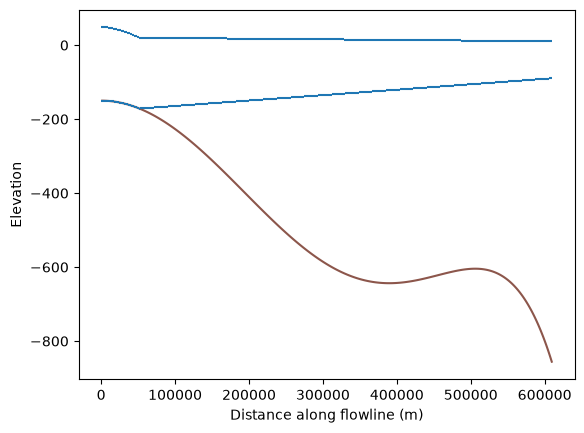

In [31]:
fig, axes = plt.subplots()
fd.plot(b, axes=axes, edgecolor="tab:brown")
fd.plot(s0, axes=axes, edgecolor="tab:blue")
fd.plot(z_b, axes=axes, edgecolor="tab:blue")
axes.set_xlabel('Distance along flowline (m)')
axes.set_ylabel('Elevation')
plt.show()

## Setting up and solving $F$

In [32]:
δu = fd.Constant(90.0)
expr = fd.as_vector([δu * x / Lx])  # 1-component vector
u_0 = fd.Function(V).interpolate(expr)

In [33]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** n)
u_c = Constant(K * τ_c ** m)

In [34]:
print(f"Strain rate: {1000 * float(ε_c):0.3f} m / yr / km")
print(f"Speed:       {float(u_c):0.3f} m / yr")
print(f"at stress of {1000 * float(τ_c):0.3f} kPa")

Strain rate: 0.020 m / yr / km
Speed:       1.000 m / yr
at stress of 10.000 kPa


In [35]:
"""
Initialization of function spaces and mass/momentum balance
"""

Z = V * Σ * V
z = fd.Function(Z)
z.sub(0).assign(u_0);

inflow_ids = (1,)
terminus_ids = (2,)

#s = smooth_max(b + h, (1 - ρ_I / ρ_W) * h, ϵ)
s = max_value(b + h, (1 - ρ_I / ρ_W) * h)

u, M, τ = fd.split(z)
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

parameters_1 = {
    "flow_law_coefficient": ε_c / τ_c,
    "flow_law_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
    "sliding_exponent": 1,
}

parameters_3 = {
    "flow_law_coefficient": ε_c / τ_c ** n,
    "flow_law_exponent": n,
    "sliding_coefficient": u_c / τ_c ** m,
    "sliding_exponent": m,
}

α = Constant(1e-3)
F_flow_law_1 = flow_law(mesh_dim, **fields, **parameters_1)
F_flow_law_3 = flow_law(**fields, **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**fields, **parameters_1)
F_sliding_law_3 = friction_law(**fields, **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F = F_flow_law + F_sliding_law + F_balance + F_terminus

inflow_bc = fd.DirichletBC(Z.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

fparams = {"quadrature_degree": 8}
pparams = {"bcs": bcs, "form_compiler_parameters": fparams}
problem = fd.NonlinearVariationalProblem(F, z, **pparams)

logfile = ":mismipp-dual.log"
sparams = {
    "solver_parameters": {
        "snes_max_it": 200,
        "snes_linesearch_type": "nleqerr",
        "snes_monitor": logfile,
        "pc_factor_mat_solver_type": "umfpack",
    }
}
solver = fd.NonlinearVariationalSolver(problem, **sparams)
solver.solve()
u, M, τ = z.subfunctions

TypeError: flow_law() missing 1 required positional argument: 'dimension'